In [1]:
import numpy as np
from src.fortran.reflectivity_benchmark import numpy_reflectivity_p
from src.utilities import get_critical_angles
from src.plot.plot_tools import plot_reflectivity, set_plot_style, plot_reflectivity_complex_plane
set_plot_style()

Layers 0→1: vp 1700→2800 m/s, critical angle = 37.38°
2 layers reflectivity without free surface


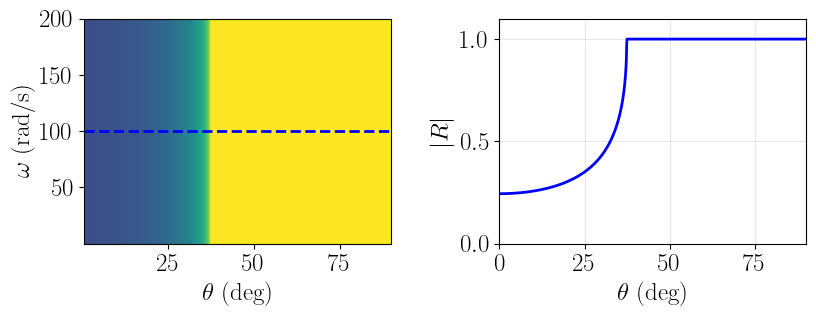

In [2]:
layers = [
        (100.0, 1700.0, 2000.0),
        (150.0, 2800.0, 2000.0),
    ]
get_critical_angles(layers)

thetas = np.linspace(0.01, np.pi/2., 1024)  # 0-90 deg
omegas = np.linspace(0.01, 200, 1024)
p = np.sin(thetas) / layers[0][1]

print('2 layers reflectivity without free surface')
Rmap = numpy_reflectivity_p(layers, omegas, p, free_surface=0)
plot_reflectivity(omegas, thetas, Rmap, omega_c=100., figsize=(8.5,3.5))

Layers 0→1: vp 1700→2100 m/s, critical angle = 54.05°
Layers 0→2: vp 1700→2400 m/s, critical angle = 45.10°
Layers 1→2: vp 2100→2400 m/s, critical angle = 61.04°
3 layers reflectivity without free surface


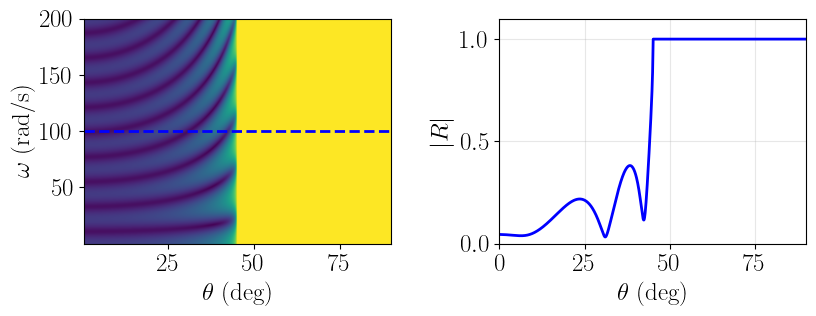

In [3]:
layers = [
        (50.0, 1700.0, 2000.0),
        (300.0, 2100.0, 2000.0),
        (100.0, 2400.0, 2000.0),
    ]
get_critical_angles(layers, include_non_adjacent=True)

print('3 layers reflectivity without free surface')
Rmap = numpy_reflectivity_p(layers, omegas, p, free_surface=0)
plot_reflectivity(omegas, thetas, Rmap, omega_c=100., figsize=(8.5,3.5))

Layers 0→1: vp 1700→2000 m/s, critical angle = 58.21°
Layers 0→2: vp 1700→1800 m/s, critical angle = 70.81°
Layers 0→3: vp 1700→2800 m/s, critical angle = 37.38°
Layers 0→4: vp 1700→3500 m/s, critical angle = 29.06°
Layers 1→2: vp 2000→1800 m/s, no critical angle (velocity decrease)
Layers 1→3: vp 2000→2800 m/s, critical angle = 45.58°
Layers 1→4: vp 2000→3500 m/s, critical angle = 34.85°
Layers 2→3: vp 1800→2800 m/s, critical angle = 40.01°
Layers 2→4: vp 1800→3500 m/s, critical angle = 30.95°
Layers 3→4: vp 2800→3500 m/s, critical angle = 53.13°
3 layers reflectivity with free surface


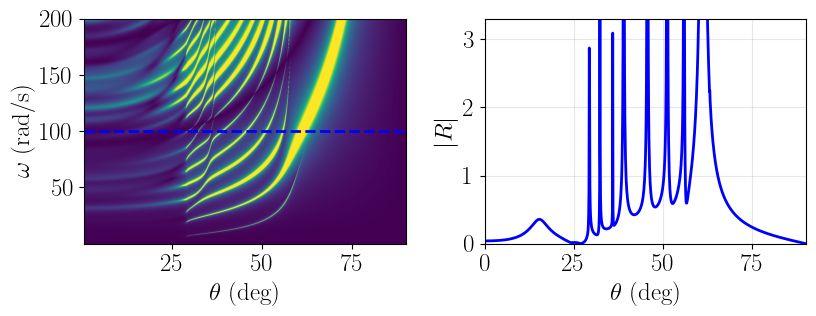

In [4]:
layers = [
        (70.0, 1700.0, 2000.0),
        (300.0, 2000.0, 2000.0),
        (100.0, 1800.0, 2000.0),
        (300.0, 2800.0, 2000.0),
        (200.0, 3500.0, 2000.0),
    ]
get_critical_angles(layers, include_non_adjacent=True)

print('3 layers reflectivity with free surface')
Rmap = numpy_reflectivity_p(layers, omegas, p, free_surface=1, zr=60., zs=10.)
plot_reflectivity(omegas, thetas, Rmap, omega_c=100., figsize=(8.5,3.5))

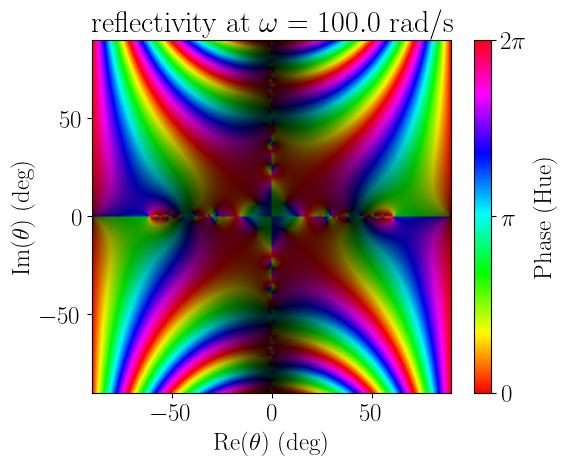

In [6]:
re = np.linspace(-np.pi/2., np.pi/2., 800)   # Real part (-90 to 90 degrees)
im = np.linspace(-np.pi/2., np.pi/2., 800)   # Imaginary part
# zoom
# re = np.linspace(0.4, 0.6, 800)
# im = np.linspace(-0.1, 0.1, 800)

Re_th, Im_th = np.meshgrid(re, im)
Z_theta = Re_th + 1j * Im_th
omega_val = np.array([100.0])
p_mesh = np.sin(Z_theta).flatten() / layers[0][1]
R_mesh = numpy_reflectivity_p(layers, omega_val, p_mesh, free_surface=1).reshape(Z_theta.shape)

fig, ax = plot_reflectivity_complex_plane(R_mesh, re, im, title=fr'reflectivity at $\omega = {omega_val[0]:.1f}$ rad/s')